## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load & Drop the "India" total row

In [4]:
df = pd.read_csv("dropout_data.csv")

# Remove the last row — it's a national total, not a state
df = df[df["State/UT"] != "India"].reset_index(drop=True)
print("States after cleaning:", len(df))

States after cleaning: 37


## Reshape

In [5]:
# Melt all year-level columns into rows
df_long = df.melt(id_vars="State/UT", var_name="Year_Level", value_name="Dropout_Rate")

# Split "2019-20 - Secondary (IX-X)" into Year and Level columns
df_long["Year"] = df_long["Year_Level"].str[:7]  # "2019-20"
df_long["Level"] = df_long["Year_Level"].str.split(" - ").str[1]  # "Secondary (IX-X)"

# Clean up
df_long = df_long.drop(columns="Year_Level")
df_long = df_long.dropna(subset=["Dropout_Rate"])
df_long = df_long.reset_index(drop=True)

print("New shape:", df_long.shape)
df_long.head(10)

New shape: (327, 4)


,State/UT,Dropout_Rate,Year,Level
0,Andaman and Nicobar Islands,0.5,2019-20,Primary level (I
1,Andhra Pradesh,0.0,2019-20,Primary level (I
2,Arunachal Pradesh,6.2,2019-20,Primary level (I
3,Assam,4.3,2019-20,Primary level (I
4,Bihar,2.3,2019-20,Primary level (I
5,Chandigarh,0.0,2019-20,Primary level (I
6,Chhattisgarh,1.0,2019-20,Primary level (I
7,Dadra and Nagar Haveli,0.0,2019-20,Primary level (I
8,Daman and Diu,0.0,2019-20,Primary level (I
9,Delhi,0.0,2019-20,Primary level (I


## Create Target Variable

In [6]:
# High dropout = 1 if rate is above median, else 0
median_rate = df_long["Dropout_Rate"].median()
print("Median dropout rate:", median_rate)

df_long["High_Dropout"] = (df_long["Dropout_Rate"] > median_rate).astype(int)

print("\nTarget distribution:")
print(df_long["High_Dropout"].value_counts())
print(f"\n{df_long['High_Dropout'].mean()*100:.1f}% of records are high dropout")

Median dropout rate: 3.7

Target distribution:
High_Dropout
0    165
1    162
Name: count, dtype: int64

49.5% of records are high dropout


## Encode Categorical Columns

In [7]:
from sklearn.preprocessing import LabelEncoder

le_state = LabelEncoder()
le_level = LabelEncoder()
le_year = LabelEncoder()

df_long["State_Encoded"] = le_state.fit_transform(df_long["State/UT"])
df_long["Level_Encoded"] = le_level.fit_transform(df_long["Level"])
df_long["Year_Encoded"] = le_year.fit_transform(df_long["Year"])

print("Final dataset shape:", df_long.shape)
print("\nSample:")
df_long[["State/UT", "Year", "Level", "Dropout_Rate", "High_Dropout"]].head(10)

Final dataset shape: (327, 8)

Sample:


,State/UT,Year,Level,Dropout_Rate,High_Dropout
0,Andaman and Nicobar Islands,2019-20,Primary level (I,0.5,0
1,Andhra Pradesh,2019-20,Primary level (I,0.0,0
2,Arunachal Pradesh,2019-20,Primary level (I,6.2,1
3,Assam,2019-20,Primary level (I,4.3,1
4,Bihar,2019-20,Primary level (I,2.3,0
5,Chandigarh,2019-20,Primary level (I,0.0,0
6,Chhattisgarh,2019-20,Primary level (I,1.0,0
7,Dadra and Nagar Haveli,2019-20,Primary level (I,0.0,0
8,Daman and Diu,2019-20,Primary level (I,0.0,0
9,Delhi,2019-20,Primary level (I,0.0,0


## Save ML-ready dataset

In [8]:
df_long.to_csv("dropout_ml_ready.csv", index=False)
print("Saved dropout_ml_ready.csv")
print("Shape:", df_long.shape)

Saved dropout_ml_ready.csv
Shape: (327, 8)


##  Visualization of distribution

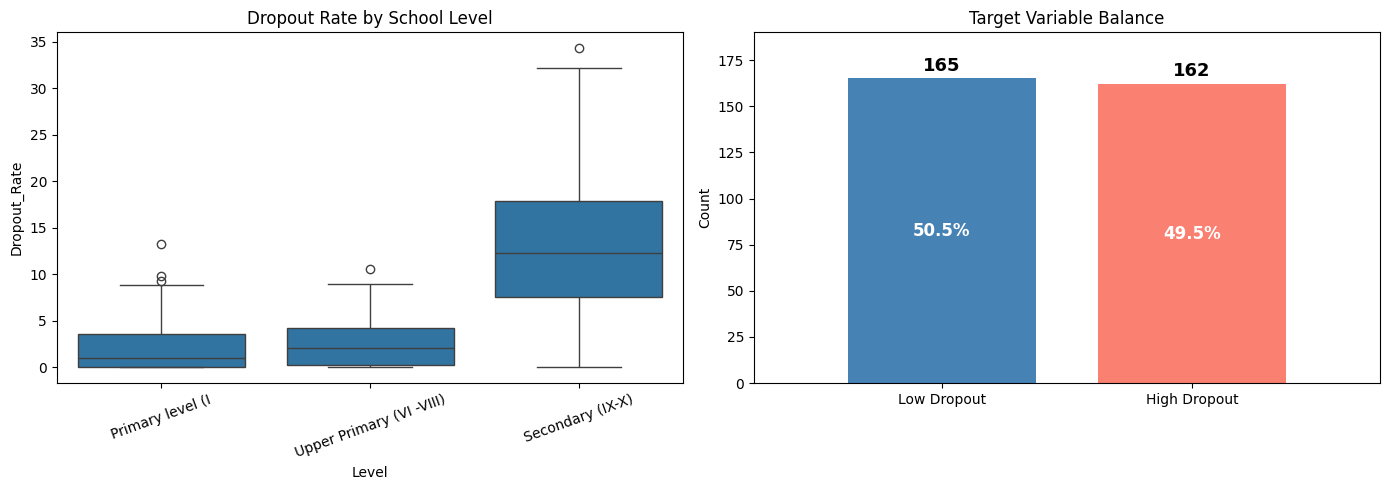

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dropout rate by level
sns.boxplot(data=df_long, x="Level", y="Dropout_Rate", ax=axes[0])
axes[0].set_title("Dropout Rate by School Level")
axes[0].tick_params(axis="x", rotation=20)

# Target variable balance
counts = df_long["High_Dropout"].value_counts().sort_index()
x_pos = [0.3, 0.7]

bars = axes[1].bar(x_pos, counts.values, color=["steelblue", "salmon"], width=0.3)

# Count above bar
for bar, count in zip(bars, counts.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(count),
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
    )
    # Percentage inside bar
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{count/len(df_long)*100:.1f}%",
        ha="center",
        va="center",
        fontsize=12,
        color="white",
        fontweight="bold",
    )

axes[1].set_title("Target Variable Balance")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(["Low Dropout", "High Dropout"])
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, max(counts.values) + 25)
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("feature_engineering_plots.png")
plt.show()

## Day 2 Summary
- Reshaped data from 37 rows → 100+ rows using melt()
- Created target variable: High_Dropout (1 if above median rate)
- Encoded State, Level, Year as numeric features
- Saved ML-ready dataset as dropout_ml_ready.csv
- Key finding: Secondary level consistently has highest dropout rates
- Next: Build first ML model (Logistic Regression) in Day 3
- Dataset is well-balanced (165 low vs 162 high dropout) — no oversampling needed